In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,Dataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

In [ ]:
train_dataset = torchvision.datasets.MNIST(
    root = "./data",
    train = True,
    download = True,
    transform = transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.48MB/s]


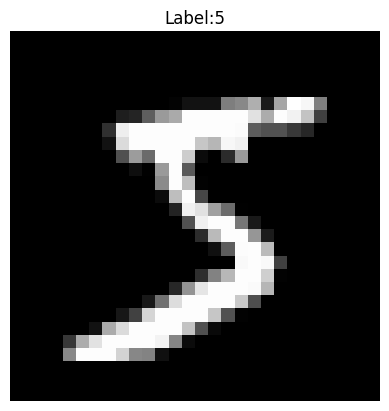

In [ ]:
image_tensor,label = train_dataset[0]
image_grid = image_tensor.squeeze()
plt.imshow(image_grid,cmap='gray')
plt.title(f"Label:{label}")
plt.axis('off')
plt.show()

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=1024,shuffle=True)
print(f"Dataset successfully loaded! Total training images: {len(train_dataset)}")

Dataset successfully loaded! Total training images: 60000


In [ ]:
class ContrastiveMNIST(Dataset):
  def __init__(self,root,train=True,download=True):
    self.standardtransform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
    self.augmentation = transforms.Compose([
            transforms.RandomRotation(degrees=15),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
    self.mnist = torchvision.datasets.MNIST(
            root=root, train=train, download=download, transform=None
        )

  def __getitem__(self,index):
    img,target = self.mnist[index]
    view1 = self.augmentation(img)
    view2 = self.augmentation(img)
    return view1,view2,target

  def __len__(self):
    return len(self.mnist)

In [ ]:
class ContrastiveEncoder(nn.Module):
  def __init__(self,embedding_dim = 128,projection_dim = 64):
    super(ContrastiveEncoder,self).__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(1,32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32,64,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Flatten(),
        nn.Linear(7*7*64,embedding_dim),
        nn.ReLU()
    )

    self.projection = nn.Sequential(
        nn.Linear(embedding_dim,embedding_dim),
        nn.ReLU(),
        nn.Linear(embedding_dim,projection_dim)
    )

  def forward(self,x):
    embeding = self.encoder(x)
    projection = self.projection(embeding)
    return embeding,projection


In [ ]:
class InfoNCELoss(nn.Module):
    def __init__(self, batch_size, temperature=0.07):
        super(InfoNCELoss, self).__init__()
        self.batch_size = batch_size
        self.temperature = temperature
        self.mask = (~torch.eye(batch_size * 2, dtype=torch.bool))

    def forward(self, out_1, out_2):
        device = out_1.device
        out_1 = F.normalize(out_1, dim=1)
        out_2 = F.normalize(out_2, dim=1)
        out = torch.cat([out_1, out_2], dim=0)
        sim_matrix = torch.matmul(out, out.T) / self.temperature
        sim_12 = torch.diag(sim_matrix, self.batch_size)
        sim_21 = torch.diag(sim_matrix, -self.batch_size)
        positives = torch.cat([sim_12, sim_21], dim=0).view(2 * self.batch_size, 1)
        mask = self.mask.to(device)
        negatives = sim_matrix[mask].view(2 * self.batch_size, -1)
        logits = torch.cat([positives, negatives], dim=1)
        labels = torch.zeros(2 * self.batch_size, dtype=torch.long).to(device)
        loss = nn.CrossEntropyLoss()(logits, labels)
        return loss

In [ ]:

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
TEMPERATURE = 0.07
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = ContrastiveMNIST(root='./data', train=True, download=True)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

model = ContrastiveEncoder().to(DEVICE)
criterion = InfoNCELoss(batch_size=BATCH_SIZE, temperature=TEMPERATURE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

model.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for batch_idx, (view1, view2, _) in enumerate(dataloader):
        view1, view2 = view1.to(DEVICE), view2.to(DEVICE)

        optimizer.zero_grad()
        _, proj1 = model(view1)
        _, proj2 = model(view2)

        loss = criterion(proj1, proj2)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch}/{EPOCHS}] Average InfoNCE Loss: {avg_loss:.4f}")

Epoch [1/10] Average InfoNCE Loss: 1.3639
Epoch [2/10] Average InfoNCE Loss: 0.9116
Epoch [3/10] Average InfoNCE Loss: 0.8500
Epoch [4/10] Average InfoNCE Loss: 0.8239
Epoch [5/10] Average InfoNCE Loss: 0.8045
Epoch [6/10] Average InfoNCE Loss: 0.7941
Epoch [7/10] Average InfoNCE Loss: 0.7837
Epoch [8/10] Average InfoNCE Loss: 0.7794
Epoch [9/10] Average InfoNCE Loss: 0.7716
Epoch [10/10] Average InfoNCE Loss: 0.7680


In [ ]:
# 1. Freeze the pretrained base encoder architecture
model.eval()
for param in model.parameters():
    param.requires_grad = False

# 2. Define a linear probe classifier using the intermediate embedding size
linear_classifier = nn.Linear(128, 10).to(DEVICE) # 10 classes for digit outputs
classifier_optimizer = torch.optim.Adam(linear_classifier.parameters(), lr=1e-3)
classifier_criterion = nn.CrossEntropyLoss()

# 3. Load standard un-augmented data splits
standard_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_mnist = torchvision.datasets.MNIST(root='./data', train=True, transform=standard_transform)
train_loader = DataLoader(train_mnist, batch_size=BATCH_SIZE, shuffle=True)

# 4. Train the linear classifier layer
print("\n--- Training Linear Evaluation Probe ---")
for epoch in range(3): # Only 3 quick iterations needed to check representation quality
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        classifier_optimizer.zero_grad()

        # Generate static embeddings using the frozen encoder
        with torch.no_grad():
            embeddings, _ = model(images)

        outputs = linear_classifier(embeddings)
        loss = classifier_criterion(outputs, labels)

        loss.backward()
        classifier_optimizer.step()

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    print(f"Probe Epoch [{epoch+1}/3] Training Accuracy: {(correct/total)*100:.2f}%")


--- Training Linear Evaluation Probe ---
Probe Epoch [1/3] Training Accuracy: 87.40%
Probe Epoch [2/3] Training Accuracy: 95.92%
Probe Epoch [3/3] Training Accuracy: 96.58%


### 5. Evaluate the linear classifier on the test set

### 6. Compare Pre-trained vs. From Scratch Training with Varying Data Sizes

Now, let's compare the performance of our pre-trained encoder (with a linear probe) against a brand new encoder trained from scratch, both on different subsets of the training data. The evaluation will always be performed on the full 10,000-sample test set.

In [ ]:
import copy

# Re-define constants for clarity and potential modification
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Standard transformation (already defined, but ensuring it's available)
standard_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the full MNIST training and test datasets
train_mnist_full = torchvision.datasets.MNIST(root='./data', train=True, transform=standard_transform)
test_mnist_full = torchvision.datasets.MNIST(root='./data', train=False, transform=standard_transform)
test_loader = DataLoader(test_mnist_full, batch_size=BATCH_SIZE, shuffle=False)


def evaluate_model(encoder, classifier, test_loader, device):
    """Evaluates a given encoder and classifier on the test set."""
    encoder.eval()
    classifier.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            embeddings, _ = encoder(images)
            outputs = classifier(embeddings)
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
    return (correct / total) * 100


def train_linear_probe(pretrained_encoder, train_loader_subset, test_loader, device, epochs=5):
    """Trains and evaluates a linear probe on top of a frozen pre-trained encoder."""
    print(f"  Training linear probe on {len(train_loader_subset.dataset)} samples...")

    # Ensure the pretrained encoder is frozen
    pretrained_encoder.eval()
    for param in pretrained_encoder.parameters():
        param.requires_grad = False

    linear_classifier = nn.Linear(128, 10).to(device)
    classifier_optimizer = torch.optim.Adam(linear_classifier.parameters(), lr=LEARNING_RATE)
    classifier_criterion = nn.CrossEntropyLoss()

    best_accuracy = 0.0

    for epoch in range(epochs):
        linear_classifier.train()
        for images, labels in train_loader_subset:
            images, labels = images.to(device), labels.to(device)

            classifier_optimizer.zero_grad()

            with torch.no_grad():
                embeddings, _ = pretrained_encoder(images)

            outputs = linear_classifier(embeddings)
            loss = classifier_criterion(outputs, labels)

            loss.backward()
            classifier_optimizer.step()

        # Optional: Evaluate on test set after each epoch to find best model
        current_accuracy = evaluate_model(pretrained_encoder, linear_classifier, test_loader, device)
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy

    return best_accuracy


def train_from_scratch(train_loader_subset, test_loader, device, epochs=10):
    """Trains an encoder and a linear classifier from scratch."""
    print(f"  Training from scratch on {len(train_loader_subset.dataset)} samples...")

    encoder_scratch = ContrastiveEncoder().to(device)
    classifier_scratch = nn.Linear(128, 10).to(device) # Assuming 128 embedding dim from ContrastiveEncoder

    # Combine parameters for end-to-end training
    optimizer = torch.optim.Adam(list(encoder_scratch.parameters()) + list(classifier_scratch.parameters()), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    best_accuracy = 0.0

    for epoch in range(epochs):
        encoder_scratch.train()
        classifier_scratch.train()
        for images, labels in train_loader_subset:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            embeddings, _ = encoder_scratch(images)
            outputs = classifier_scratch(embeddings)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        # Optional: Evaluate on test set after each epoch to find best model
        current_accuracy = evaluate_model(encoder_scratch, classifier_scratch, test_loader, device)
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy

    return best_accuracy


In [ ]:
from torch.utils.data import Subset

training_data_sizes = [100, 250, 500, 1000, 2500, 5000, 10000]
pretrained_accuracies = []
scratch_accuracies = []

print("Starting comparison...")

for size in training_data_sizes:
    print(f"\nProcessing with training data size: {size}")

    # Create a subset of the training data
    indices = torch.randperm(len(train_mnist_full))[:size]
    train_subset = Subset(train_mnist_full, indices)
    train_loader_subset = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)

    # --- Pre-trained model evaluation ---
    # Create a deep copy of the original pre-trained model to ensure it's not modified
    # and is in the same state for each data size iteration.
    # The 'model' variable from previous cells holds the pre-trained encoder.
    cloned_pretrained_encoder = copy.deepcopy(model).to(DEVICE)
    acc_pretrained = train_linear_probe(cloned_pretrained_encoder, train_loader_subset, test_loader, DEVICE)
    pretrained_accuracies.append(acc_pretrained)
    print(f"  Pre-trained encoder + linear probe accuracy: {acc_pretrained:.2f}%")

    # --- From scratch model evaluation ---
    # Train a new encoder and classifier from scratch
    acc_scratch = train_from_scratch(train_loader_subset, test_loader, DEVICE)
    scratch_accuracies.append(acc_scratch)
    print(f"  From scratch (encoder+classifier) accuracy: {acc_scratch:.2f}%")

print("\nComparison complete.")

Starting comparison...

Processing with training data size: 100
  Training linear probe on 100 samples...
  Pre-trained encoder + linear probe accuracy: 6.06%
  Training from scratch on 100 samples...
  From scratch (encoder+classifier) accuracy: 72.88%

Processing with training data size: 250
  Training linear probe on 250 samples...
  Pre-trained encoder + linear probe accuracy: 19.07%
  Training from scratch on 250 samples...
  From scratch (encoder+classifier) accuracy: 80.29%

Processing with training data size: 500
  Training linear probe on 500 samples...
  Pre-trained encoder + linear probe accuracy: 39.40%
  Training from scratch on 500 samples...
  From scratch (encoder+classifier) accuracy: 88.75%

Processing with training data size: 1000
  Training linear probe on 1000 samples...
  Pre-trained encoder + linear probe accuracy: 71.71%
  Training from scratch on 1000 samples...
  From scratch (encoder+classifier) accuracy: 93.30%

Processing with training data size: 2500
  Tra

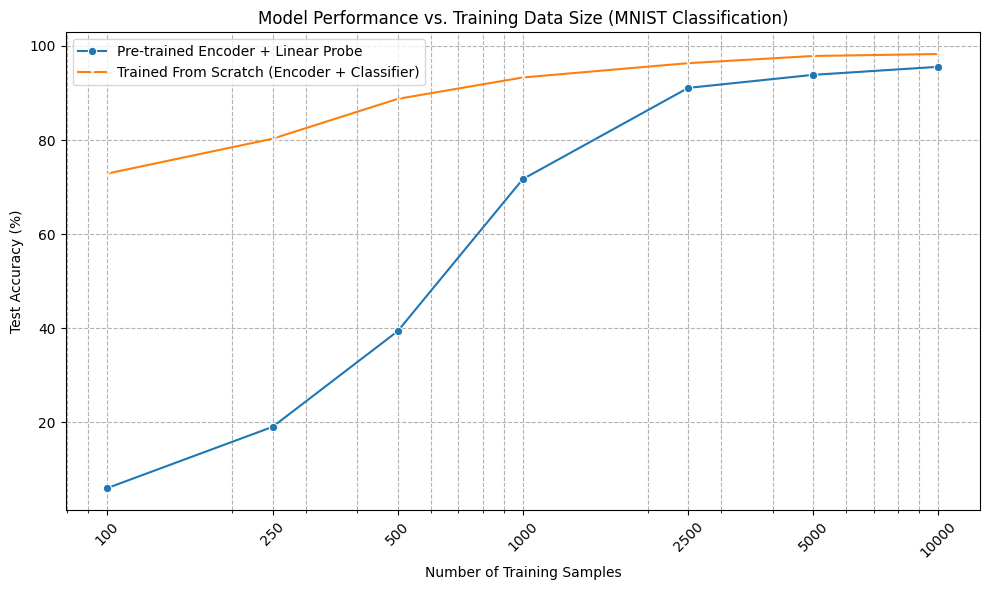

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x=training_data_sizes, y=pretrained_accuracies, marker='o', label='Pre-trained Encoder + Linear Probe')
sns.lineplot(x=training_data_sizes, y=scratch_accuracies, marker='x', label='Trained From Scratch (Encoder + Classifier)')

plt.title('Model Performance vs. Training Data Size (MNIST Classification)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Test Accuracy (%)')
plt.xscale('log') # Use a log scale for x-axis as data sizes vary widely
plt.xticks(training_data_sizes, labels=[str(s) for s in training_data_sizes], rotation=45)
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()


### 7. Visualize Embeddings with PCA

Let's apply Principal Component Analysis (PCA) to the embeddings generated by our pre-trained `ContrastiveEncoder` on the training dataset. We'll reduce the embeddings to two dimensions and visualize them, coloring points by their true labels, to see how well the different digit classes are separated in the learned embedding space.

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to(DEVICE)

# Prepare to collect embeddings and labels for the entire training set
all_embeddings = []
all_labels = []

# We use the full training dataset with standard transformations for embedding extraction
train_mnist_full_for_pca = torchvision.datasets.MNIST(root='./data', train=True, transform=standard_transform)
train_loader_for_pca = DataLoader(train_mnist_full_for_pca, batch_size=BATCH_SIZE, shuffle=False)

print("Extracting embeddings from the pre-trained model...")
with torch.no_grad():
    for images, labels in train_loader_for_pca:
        images = images.to(DEVICE)
        embeddings, _ = model(images)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Concatenate all collected embeddings and labels
all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Total embeddings extracted: {all_embeddings.shape[0]}")
print(f"Embedding dimension: {all_embeddings.shape[1]}")

# Perform PCA to reduce embeddings to 2 dimensions
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

print(f"Embeddings reduced to 2 dimensions: {reduced_embeddings.shape}")

Extracting embeddings from the pre-trained model...
Total embeddings extracted: 60000
Embedding dimension: 128
Embeddings reduced to 2 dimensions: (60000, 2)


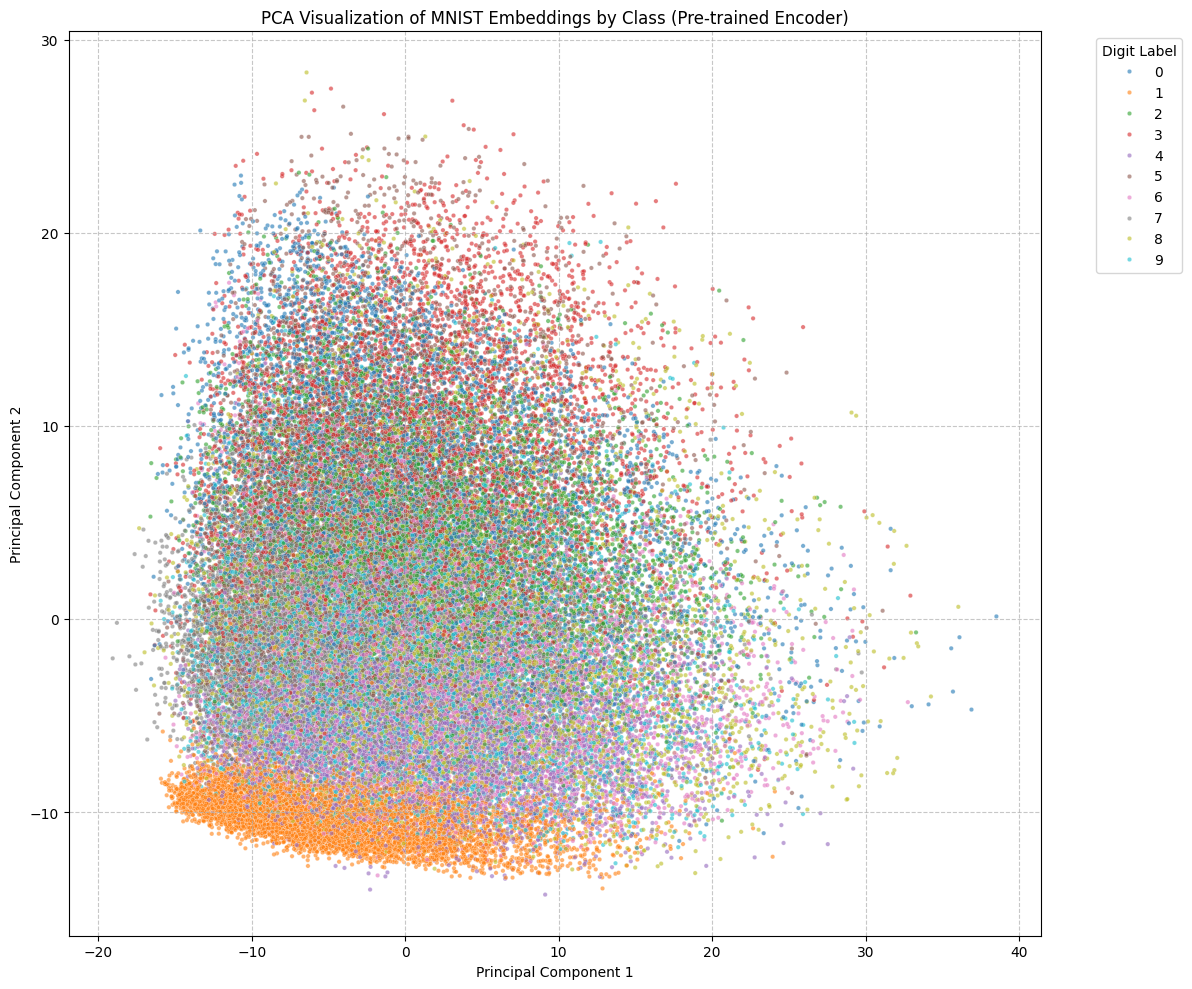

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=reduced_embeddings[:, 0],
    y=reduced_embeddings[:, 1],
    hue=all_labels,
    palette=sns.color_palette("tab10", n_colors=10),
    legend='full',
    alpha=0.6,
    s=10 # Smaller point size for potentially large number of points
)

plt.title('PCA Visualization of MNIST Embeddings by Class (Pre-trained Encoder)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Digit Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
test_mnist = torchvision.datasets.MNIST(root='./data', train=False, transform=standard_transform)
test_loader = DataLoader(test_mnist, batch_size=BATCH_SIZE, shuffle=False)

linear_classifier.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Get embeddings from the frozen encoder
        embeddings, _ = model(images)

        # Classify with the linear probe
        outputs = linear_classifier(embeddings)
        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

print(f"\n--- Linear Evaluation on Test Set ---")
print(f"Test Accuracy: {(correct/total)*100:.2f}%")


--- Linear Evaluation on Test Set ---
Test Accuracy: 97.07%
